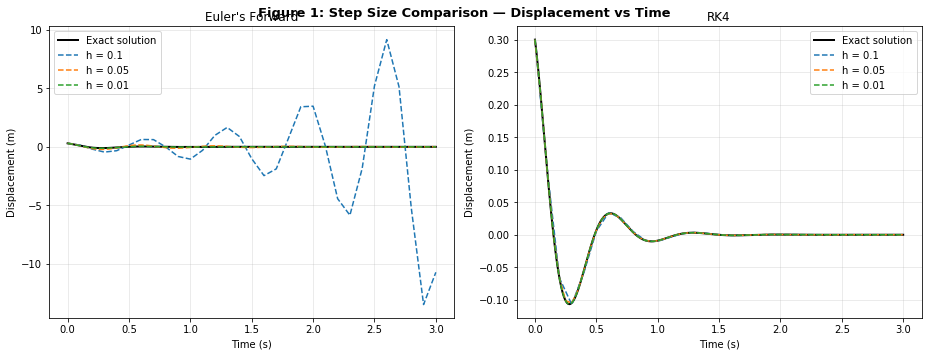

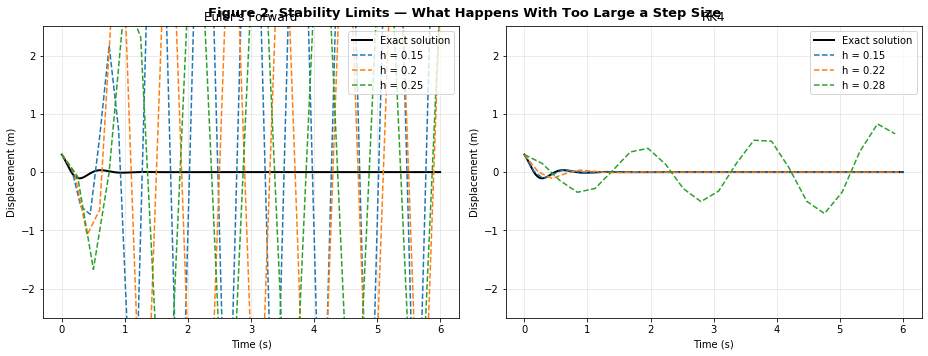

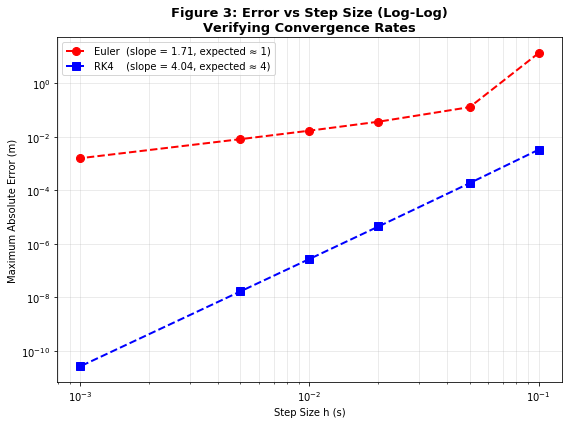


Euler slope: 1.71  (should be close to 1)
RK4   slope: 4.04  (should be close to 4)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS

damping_ratio   = 0.95
frequency       = 18.85   #3hz converted to rad/s
initial_x       = 0.0     
velocity_impact = 3.048   
time            = 5.0    

# SYSTEM OF EQUATIONS

def equations(x1, x2):
    # x1 = displacement, x2 = velocity
    dx1 = x2
    dx2 = -frequency**2 * x1 - 2 * damping_ratio * frequency * x2
    return dx1, dx2

# EULER METHOD

def euler(h):
    steps = int(time / h)
    t  = np.zeros(steps + 1)
    x1 = np.zeros(steps + 1)
    x2 = np.zeros(steps + 1)
    t[0]  = 0
    x1[0] = initial_x
    x2[0] = velocity_impact
    for i in range(steps):
        dx1, dx2 = equations(x1[i], x2[i])
        t[i+1]  = t[i] + h
        x1[i+1] = x1[i] + h * dx1
        x2[i+1] = x2[i] + h * dx2
    return t, x1


# RK4 METHOD

def rk4(h):
    steps = int(time / h)
    t  = np.zeros(steps + 1)
    x1 = np.zeros(steps + 1)
    x2 = np.zeros(steps + 1)
    t[0]  = 0
    x1[0] = initial_x
    x2[0] = velocity_impact
    for i in range(steps):
        k1a, k1b = equations(x1[i],           x2[i])
        k2a, k2b = equations(x1[i]+h/2*k1a,   x2[i]+h/2*k1b)
        k3a, k3b = equations(x1[i]+h/2*k2a,   x2[i]+h/2*k2b)
        k4a, k4b = equations(x1[i]+h*k3a,     x2[i]+h*k3b)
        t[i+1]  = t[i] + h
        x1[i+1] = x1[i] + (h/6)*(k1a + 2*k2a + 2*k3a + k4a)
        x2[i+1] = x2[i] + (h/6)*(k1b + 2*k2b + 2*k3b + k4b)
    return t, x1


# EXACT SOLUTION 

def exact(t):
    wd = frequency * np.sqrt(1 - damping_ratio**2)
    A  = initial_x
    B  = (velocity_impact + damping_ratio * frequency * initial_x) / wd
    return np.exp(-damping_ratio * frequency * t) * (A * np.cos(wd * t) + B * np.sin(wd * t))


# FIGURE 1: How accuracy changes with step size

t_exact = np.linspace(0, time, 1000)

#Euler plot
plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-', label='Exact solution')
t1, y1 = euler(0.1)
plt.plot(t1, y1, 'r--', label='h = 0.1')
t2, y2 = euler(0.05)
plt.plot(t2, y2, 'b--', label='h = 0.05')
t3, y3 = euler(0.01)
plt.plot(t3, y3, 'g--', label='h = 0.01')
plt.title("Figure 1a: Euler's Method — Step Size Comparison")
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()

# RK4 plot
plt.figure()
plt.plot(t_exact, exact(t_exact), 'k-',label='Exact solution')
t1, y1 = rk4(0.1)
plt.plot(t1, y1, 'r--', label='h = 0.1')
t2, y2 = rk4(0.05)
plt.plot(t2, y2, 'b--', label='h = 0.05')
t3, y3 = rk4(0.01)
plt.plot(t3, y3, 'g--', label='h = 0.01')
plt.title('Figure 1b: RK4 — Step Size Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()


# FIGURE 2: What happens when step size is too large (instability)

t_exact_long = np.linspace(0, time, 1000)

#Euler instability
plt.figure()
plt.plot(t_exact_long, exact(t_exact_long), 'k-', linewidth=2, label='Exact solution')
t1, y1 = euler(0.05)
plt.plot(t1, y1, 'g--', label='h = 0.05 (stable)')
t2, y2 = euler(0.10)
plt.plot(t2, y2, 'b--', label='h = 0.10 (less stable)')
t3, y3 = euler(0.15)
y3 = np.clip(y3, -1, 1)
plt.plot(t3, y3, 'r--', label='h = 0.15 (unstable)')
plt.title("Figure 2a: Euler's Method — Instability at Large Step Sizes")
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()

#RK4 instability
plt.figure()
plt.plot(t_exact_long, exact(t_exact_long), 'k-', linewidth=2, label='Exact solution')
t1, y1 = rk4(0.05)
plt.plot(t1, y1, 'g--', label='h = 0.05 (stable)')
t2, y2 = rk4(0.10)
plt.plot(t2, y2, 'b--', label='h = 0.10 (stable)')
t3, y3 = rk4(0.15)
y3 = np.clip(y3, -1, 1)
plt.plot(t3, y3, 'r--', label='h = 0.15 (unstable)')
plt.title('Figure 2b: RK4 — Instability at Large Step Sizes')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.show()

# FIGURE 3: Log-log error plot (proves convergence rates)

h_list = [0.1, 0.05, 0.02, 0.01, 0.005, 0.001]
euler_errors = []
rk4_errors   = []

for h in h_list:
    t_e, y_e = euler(h)
    t_r, y_r = rk4(h)
    euler_errors.append(np.max(np.abs(y_e - exact(t_e))))
    rk4_errors.append(np.max(np.abs(y_r - exact(t_r))))

h_arr = np.array(h_list)
slope_euler = np.polyfit(np.log(h_arr), np.log(euler_errors), 1)[0]
slope_rk4   = np.polyfit(np.log(h_arr), np.log(rk4_errors),   1)[0]

plt.figure()
plt.loglog(h_arr, euler_errors, 'ro--', linewidth=2, markersize=8, label=f"Euler  (slope = {slope_euler:.2f}, expected = 1)")
plt.loglog(h_arr, rk4_errors,  'bs--', linewidth=2, markersize=8, label=f"RK4    (slope = {slope_rk4:.2f}, expected = 4)")
plt.title('Figure 3: Error vs Step Size (Log-Log)\nVerifying Convergence Rates')
plt.xlabel('Step Size h (s)')
plt.ylabel('Maximum Error (m)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Euler slope: {slope_euler:.2f}  (should be close to 1)")
print(f"RK4   slope: {slope_rk4:.2f}  (should be close to 4)")

dont use loglog and dont use the f stuff when printing 